In [1]:
import ssl
import nltk

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

# Sekarang bisa download
nltk.download('punkt')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to /Users/divaoncom/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/divaoncom/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Batches:   0%|          | 0/238 [00:00<?, ?it/s]

2025-08-08 14:20:11,545 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggi

Error mcs=5, ms=10: No outliers to reduce.


2025-08-08 14:22:41,490 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggi

Error mcs=10, ms=5: No outliers to reduce.
Error mcs=10, ms=10: No outliers to reduce.
Error mcs=15, ms=3: No outliers to reduce.
Error mcs=15, ms=5: No outliers to reduce.
Error mcs=15, ms=10: No outliers to reduce.


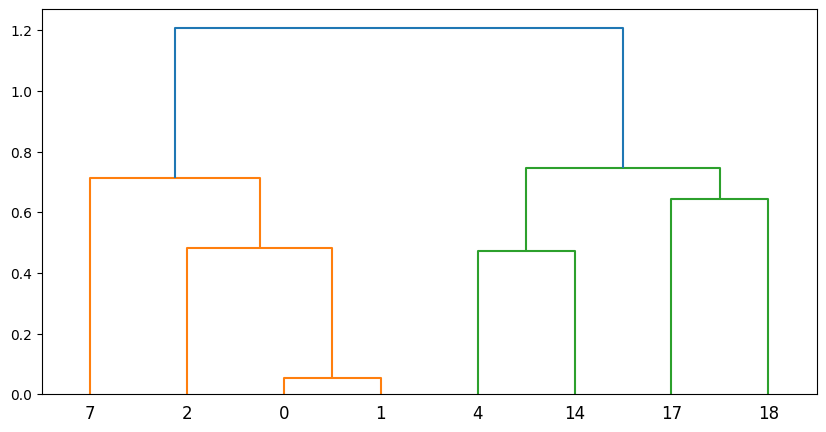

Persentase noise akhir: 40.09%
Total topik setelah merge otomatis: 18
Coherence C_v model terpilih: 0.3637
Davies-Bouldin Index model terpilih: 2.8719


In [4]:
import pandas as pd
import numpy as np
from bertopic import BERTopic
from bertopic.representation import MaximalMarginalRelevance
from hdbscan import HDBSCAN
from sklearn.metrics import davies_bouldin_score
from sentence_transformers import SentenceTransformer
from langdetect import detect, DetectorFactory
from sklearn.metrics.pairwise import cosine_similarity
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import fcluster
from collections import defaultdict
import matplotlib.pyplot as plt
from gensim.corpora.dictionary import Dictionary
from gensim.models import CoherenceModel
import warnings
import umap

warnings.filterwarnings("ignore")
DetectorFactory.seed = 0
np.random.seed(42)

# ===============================
# 1. Load & Preprocess Data
# ===============================
umap_model = umap.UMAP(n_neighbors=15, n_components=5, metric="cosine", random_state=42)

df = pd.read_csv("embedding_umap.csv")
df = df[df["cleaned_Reviews"].notnull() & df["cleaned_Reviews"].str.strip().astype(bool)]
df = df[df["cleaned_Reviews"].apply(lambda x: isinstance(x, str))]
df = df[df["cleaned_Reviews"].str.split().str.len() >= 5]              # filter too-short reviews
df["lang"] = df["cleaned_Reviews"].apply(lambda x: detect(x) if len(x.strip()) > 5 else "unknown")
df = df[df["lang"] == "en"]
docs = df["cleaned_Reviews"].tolist()

# ===============================
# 2. Embedding
# ===============================
emb_model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = emb_model.encode(docs, show_progress_bar=True)
rep_model = MaximalMarginalRelevance(diversity=0.3, top_n_words=30)

# ===============================
# 3. Seed Topic List (Guided)
# ===============================
seed_topic_list = [
    # Graphics & Visuals
    ["graphics", "visual", "texture", "animation", "animated", "art", "rendering", "render", "design", "lighting", 
     "environment", "resolution", "shaders", "shader", "models", "modeling", "assets", "asset", "detail", "details", 
     "color", "colours", "effects", "style", "polish", "cinematics", "aesthetics", "drawdistance", "framerate", 
     "visuals", "landscape", "skybox", "particle", "particles", "depth", "reflection", "shadow", "textures", "vfx"],

    # Performance & Stability
    ["performance", "fps", "frame", "frames", "lag", "lags", "stutter", "freeze", "frozen", "optimization", "latency", 
     "smooth", "crash", "crashes", "bug", "bugs", "glitch", "glitches", "loadtime", "loading", "stability", "patch", 
     "patches", "update", "updates", "benchmark", "drop", "drops", "hiccup", "overheating", "heat", "bottleneck", 
     "slow", "slowdown", "hang", "fpsdrop", "performanceissue"],

    # Sound & Audio
    ["sound", "audio", "music", "sfx", "voice", "soundtrack", "volume", "ambient", "ambience", "effects", "dialog", 
     "dialogue", "mixing", "orchestration", "melody", "rhythm", "tune", "echo", "noise", "soundscape", "vocal", 
     "vocals", "backgroundmusic", "ost", "instrumental", "chorus", "bass", "treble", "sounddesign", "audioengine"],

    # Mechanics & Gameplay
    ["mechanics", "gameplay", "controls", "movement", "combat", "interaction", "difficulty", "progression", "features", 
     "missions", "mission", "puzzle", "puzzles", "challenge", "challenges", "balance", "balancing", "leveling", 
     "system", "systems", "customization", "customise", "customizing", "skilltree", "skills", "upgrade", "upgrades", 
     "replayability", "sandbox", "simulation", "questing", "crafting", "exploration", "explore", "stealth", "shooting", 
     "aiming", "mechanic", "gameplayloop", "builds", "grind", "farming"],

    # Story & Narrative
    ["story", "plot", "narrative", "dialogue", "cutscene", "cutscenes", "lore", "writing", "quest", "quests", "ending", 
     "endings", "twist", "chapter", "chapters", "theme", "themes", "conflict", "climax", "motivation", "subplot", 
     "subplots", "scenario", "worldbuilding", "prologue", "epilogue", "storyline", "plotline", "arcs", "arc", "backstory", 
     "monologue", "script", "screenplay", "dialogues", "cinematic", "storytelling"],

    # Characters
    ["character", "characters", "npc", "npcs", "protagonist", "protagonists", "antagonist", "antagonists", "emotion", 
     "emotions", "personality", "backstory", "development", "developments", "villain", "villains", "hero", "heroes", 
     "companion", "companions", "ally", "allies", "rival", "rivals", "cast", "avatar", "avatars", "relation", 
     "relationships", "interaction", "interactions", "dialogue", "portrayal", "faces", "models", "voiceacting", "voiceactor"],

    # UI & UX
    ["ui", "menu", "menus", "hud", "interface", "interfaces", "usability", "navigation", "accessibility", "button", 
     "buttons", "layout", "layouts", "tooltip", "tooltips", "indicator", "indicators", "minimap", "cursor", "overlay", 
     "prompt", "prompts", "hotkey", "hotkeys", "scroll", "tab", "tabs", "panel", "panels", "widget", "widgets", "icon", "icons"],

    # Multiplayer & Online Features
    ["multiplayer", "co-op", "coop", "online", "pvp", "matchmaking", "lobby", "lobbies", "server", "servers", "ping", 
     "latency", "guild", "clan", "raids", "raid", "team", "teams", "party", "parties", "leaderboard", "leaderboards", 
     "ranking", "rankings", "chat", "voicechat", "crossplay", "cooperative", "teammates", "friendlist", "invite", "invites", 
     "spectator", "spectate"],

    # Monetization & Economy
    ["monetization", "dlc", "microtransaction", "microtransactions", "lootbox", "lootboxes", "skins", "cosmetic", 
     "cosmetics", "premium", "subscription", "subscriptions", "pass", "seasonpass", "currency", "coins", "tokens", 
     "shop", "shops", "store", "stores", "marketplace", "gacha", "unlock", "unlocks", "paywall", "in-app", "purchasable", 
     "buy", "purchase", "purchases", "sale", "sales", "bundle", "bundles", "offer", "offers"]
]


# ===============================
# 4. Grid Search Topic Modeling
# ===============================
results = []
for mcs in [5, 10, 15]:
    for ms in [3, 5, 10]:
        try:
            # gunakan Euclidean pada HDBSCAN
            hdb = HDBSCAN(min_cluster_size=mcs, min_samples=ms, metric="euclidean", prediction_data=True)
            model = BERTopic(
                umap_model=umap_model,
                hdbscan_model=hdb,
                embedding_model=emb_model,
                representation_model=rep_model,
                seed_topic_list=seed_topic_list,
                calculate_probabilities=True,
                verbose=False
            )
            topics, probs = model.fit_transform(docs, embeddings)

            # reduce outliers dengan threshold lebih longgar
            reduced = model.reduce_outliers(
                docs, topics, strategy="probabilities", probabilities=probs, threshold=0.05
            )
            model.update_topics(docs, topics=reduced, representation_model=rep_model)

            # naikkan jumlah topik maksimal menjadi 25
            model = model.reduce_topics(docs, nr_topics=25)

            labels = np.array(model.topics_)
            valid = labels != -1
            dbi = davies_bouldin_score(embeddings[valid], labels[valid]) if valid.sum() > 1 else np.nan
            noise = round(1 - valid.mean(), 2)

            tokenized = [d.split() for d in docs]
            dict_ = Dictionary(tokenized)
            topic_words = [
                [w for w, _ in model.get_topic(t)]
                for t in model.get_topic_freq()["Topic"]
                if t != -1 and model.get_topic(t)
            ]
            cv = CoherenceModel(
                topics=topic_words,
                texts=tokenized,
                dictionary=dict_,
                coherence='c_v'
            ).get_coherence()

            results.append((dbi, noise, cv, model, labels))
        except Exception as e:
            print(f"Error mcs={mcs}, ms={ms}: {e}")
            continue

# ===============================
# 5. Pilih Model Terbaik
# ===============================
if any(r[1] <= 0.5 for r in results):
    cands = [r for r in results if r[1] <= 0.5]
else:
    print("⚠ Tidak ditemukan model dengan noise ≤50%, menggunakan model dengan noise terkecil.")
    cands = results
best = sorted(cands, key=lambda x: (x[0], -x[2]))[0]
final_model, final_topics = best[3], np.array(best[4])
df["topic"] = final_topics

# ===============================
# 6. Filter Topik yang Relevan
# ===============================
seed_words = sum(seed_topic_list, [])
seed_embeddings = emb_model.encode(seed_words)
seed_centroid = np.mean(seed_embeddings, axis=0)

topic_centroids = final_model.topic_embeddings_
sims = cosine_similarity([seed_centroid], topic_centroids)[0]
threshold = 0.4
valid_topics = [
    i for i, sim in enumerate(sims)
    if sim >= threshold and i in final_model.get_topic_info()["Topic"].tolist()
]
topic_centroids = [topic_centroids[i] for i in valid_topics]

# ===============================
# 7. Auto-Merge Topik Mirip
# ===============================
dist = 1 - cosine_similarity(topic_centroids)
link = sch.linkage(dist, method="ward")

plt.figure(figsize=(10, 5))
sch.dendrogram(link, labels=valid_topics)
plt.show()

ids = fcluster(link, t=1, criterion='distance')
cm = defaultdict(list)
for t, i in zip(valid_topics, ids):
    cm[i].append(t)
to_merge = [g for g in cm.values() if len(g) > 1]
final_model.merge_topics(docs, topics_to_merge=to_merge)

# ===============================
# 8. Simpan Hasil & Evaluasi
# ===============================
df["topic"] = final_model.topics_
df = df[df["topic"] != -1]             # buang noise dari output akhir
df.to_csv("hasil_topic_assignment_automerged.csv", index=False)

# daftar keywords tiap topik
kw = []
for t in final_model.get_topic_info()["Topic"]:
    if t == -1: continue
    topic_words = final_model.get_topic(t)
    if not topic_words: continue
    keywords = ", ".join([w for w, _ in topic_words])
    kw.append({"topic": t, "keywords": keywords})
pd.DataFrame(kw).to_csv("daftar_topik_keywords_automerged.csv", index=False)

# print evaluasi
arr = np.array(final_model.topics_)
noise_pct = round((arr == -1).sum() / len(arr) * 100, 2)
print(f"Persentase noise akhir: {noise_pct}%")
print(f"Total topik setelah merge otomatis: {len(kw)}")
print(f"Coherence C_v model terpilih: {best[2]:.4f}")
print(f"Davies-Bouldin Index model terpilih: {best[0]:.4f}")


# Experiment

In [12]:
import pandas as pd
import numpy as np
from bertopic import BERTopic
from bertopic.representation import MaximalMarginalRelevance
from hdbscan import HDBSCAN
from sklearn.metrics import davies_bouldin_score
from sentence_transformers import SentenceTransformer
from langdetect import detect, DetectorFactory
from sklearn.metrics.pairwise import cosine_similarity
from gensim.corpora.dictionary import Dictionary
from gensim.models import CoherenceModel
import warnings
import umap

warnings.filterwarnings("ignore")
DetectorFactory.seed = 0
np.random.seed(42)

# ===============================
# 1. Load & Preprocess Data
# ===============================
umap_model = umap.UMAP(n_neighbors=15, n_components=5, metric="cosine", random_state=42)

df = pd.read_csv("embedding_umap.csv")
df = df[df["cleaned_Reviews"].notnull() & df["cleaned_Reviews"].str.strip().astype(bool)]
df = df[df["cleaned_Reviews"].apply(lambda x: isinstance(x, str))]
df = df[df["cleaned_Reviews"].str.split().str.len() >= 5]
df["lang"] = df["cleaned_Reviews"].apply(lambda x: detect(x) if len(x.strip()) > 5 else "unknown")
df = df[df["lang"] == "en"]
docs = df["cleaned_Reviews"].tolist()

# ===============================
# 2. Embedding
# ===============================
emb_model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = emb_model.encode(docs, show_progress_bar=True)
rep_model = MaximalMarginalRelevance(diversity=0.3, top_n_words=30)

# ===============================
# 3. Seed Topic List (Guided)
# ===============================
seed_topic_list = [
    ["graphics", "visual", "texture", "animation", "art", "rendering", "design", "lighting", "environment", "resolution"],
    ["performance", "fps", "lag", "optimization", "crash", "bug", "loading", "stability"],
    ["sound", "audio", "music", "sfx", "voice", "soundtrack", "effects", "volume"],
    ["mechanics", "gameplay", "controls", "movement", "combat", "interaction", "difficulty", "progression"],
    ["story", "plot", "narrative", "dialogue", "lore", "quest", "ending", "writing"],
    ["character", "npc", "protagonist", "antagonist", "emotion", "personality", "development"],
    ["ui", "menu", "hud", "interface", "usability", "navigation", "accessibility"]
]

# ===============================
# 4. Grid Search Topic Modeling
# ===============================
results = []
for mcs in [5, 10, 15]:
    for ms in [3, 5, 10]:
        try:
            hdb = HDBSCAN(min_cluster_size=mcs, min_samples=ms, metric="euclidean", prediction_data=True)
            model = BERTopic(
                umap_model=umap_model,
                hdbscan_model=hdb,
                embedding_model=emb_model,
                representation_model=rep_model,
                seed_topic_list=seed_topic_list,
                calculate_probabilities=True,
                verbose=False
            )
            topics, probs = model.fit_transform(docs, embeddings)

            # reduce outliers with a looser threshold
            reduced = model.reduce_outliers(
                docs, topics, strategy="probabilities", probabilities=probs, threshold=0.05
            )
            model.update_topics(docs, topics=reduced, representation_model=rep_model)

            # limit number of topics to 25
            model = model.reduce_topics(docs, nr_topics=25)

            labels = np.array(model.topics_)
            valid = labels != -1
            dbi = davies_bouldin_score(embeddings[valid], labels[valid]) if valid.sum() > 1 else np.nan
            noise = round(1 - valid.mean(), 2)

            tokenized = [d.split() for d in docs]
            dict_ = Dictionary(tokenized)
            topic_words = [
                [w for w, _ in model.get_topic(t)]
                for t in model.get_topic_info()["Topic"]
                if t != -1 and model.get_topic(t)
            ]
            cv = CoherenceModel(
                topics=topic_words,
                texts=tokenized,
                dictionary=dict_,
                coherence='c_v'
            ).get_coherence()

            results.append((dbi, noise, cv, model, labels))
        except Exception as e:
            print(f"Error mcs={mcs}, ms={ms}: {e}")
            continue

# ===============================
# 5. Choose Best Model
# ===============================
if any(r[1] <= 0.5 for r in results):
    cands = [r for r in results if r[1] <= 0.5]
else:
    print("⚠ No model with noise ≤50% found, using lowest-noise model.")
    cands = results
best = sorted(cands, key=lambda x: (x[0], -x[2]))[0]
final_model, final_topics = best[3], np.array(best[4])
df["topic"] = final_topics

# ===============================
# 6. Filter Out Noise and Save
# ===============================
df = df[df["topic"] != -1]
df.to_csv("hasil_topic_assignment_no_merge.csv", index=False)

# Save topic keywords
nkw = []
for t in final_model.get_topic_info()["Topic"]:
    if t == -1:
        continue
    kws = final_model.get_topic(t)
    if not kws:
        continue
    keywords = ", ".join([w for w, _ in kws])
    nkw.append({"topic": t, "keywords": keywords})
keywords_df = pd.DataFrame(nkw)
keywords_df.to_csv("daftar_topik_keywords_no_merge.csv", index=False)

# Evaluation
arr = np.array(final_model.topics_)
noise_pct = round((arr == -1).sum() / len(arr) * 100, 2)
print(f"Final noise percentage: {noise_pct}%")
print(f"Final topic count: {len(keywords_df)}")
print(f"Coherence C_v: {best[2]:.4f}")
print(f"Davies-Bouldin Index: {best[0]:.4f}")


Batches:   0%|          | 0/238 [00:00<?, ?it/s]

2025-08-08 16:04:46,235 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggi

Error mcs=5, ms=5: No outliers to reduce.


2025-08-08 16:05:50,626 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


Error mcs=5, ms=10: Length of weights not compatible with specified axis.


...

Error mcs=10, ms=5: Length of weights not compatible with specified axis.
Error mcs=10, ms=10: No outliers to reduce.
Error mcs=15, ms=3: No outliers to reduce.


2025-08-08 16:07:20,592 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


Error mcs=15, ms=5: Length of weights not compatible with specified axis.


2025-08-08 16:07:39,387 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


Error mcs=15, ms=10: Length of weights not compatible with specified axis.
⚠ No model with noise ≤50% found, using lowest-noise model.
Final noise percentage: 51.22%
Final topic count: 24
Coherence C_v: 0.4120
Davies-Bouldin Index: 2.9804


In [1]:
import pandas as pd
import numpy as np

# 1. Load embeddings dan hasil penugasan topic
df_emb = pd.read_csv('embedding_bertopic_v2.csv')               # kolom 'Game', 'cleaned_Reviews', embedding_*
df_asg = pd.read_csv('hasil_topic_assignment_automerged.csv')     # kolom 'game', 'cleaned_reviews', 'topic', UMAP_*, dll.

# 2. Merge berdasarkan teks review (perhatikan perbedaan kapitalisasi kolom)
df = pd.merge(
    df_emb,
    df_asg[['cleaned_Reviews', 'topic']],
    left_on='cleaned_Reviews',
    right_on='cleaned_Reviews',
    how='inner'
).drop(columns=['cleaned_Reviews'])  # opsional: langsung drop setelah merge

# 3. Identifikasi semua kolom embedding
emb_cols = [c for c in df.columns if c.startswith('embedding_')]

# 4. Hitung centroid rata-rata per topic, lalu normalisasi jadi unit-vector
centroids = (
    df
    .groupby('topic')[emb_cols]
    .mean()
    .pipe(lambda df0: df0.div(np.linalg.norm(df0, axis=1), axis=0))
)

# 5. Fungsi cosine similarity (dot product karena vektor sudah unit-length)
def cosine_sim(a, b):
    return np.dot(a, b)

# 6. Hitung similarity tiap review ke centroid topiknya
#    (pastikan embedding tiap baris juga dinormalisasi)
df['similarity'] = df.apply(
    lambda r: cosine_sim(
        r[emb_cols].values / np.linalg.norm(r[emb_cols].values),
        centroids.loc[r['topic']].values
    ),
    axis=1
)

# 7. Rata-rata similarity per (Game, topic) — hanya untuk topic ≠ -1 dan ≠ 0
gt_sim = (
    df[df['topic'].isin([t for t in df['topic'].unique() if t not in (-1, 0)])]
    .groupby(['Game', 'topic'])['similarity']
    .mean()
    .reset_index()
)

# 8. Pilih topic dominan per Game (yang similarity-nya tertinggi)
idx = gt_sim.groupby('Game')['similarity'].idxmax()
dominant = gt_sim.loc[idx].reset_index(drop=True)

# 9. Rename kolom dan simpan hasil akhir
dominant = dominant.rename(columns={
    'Game': 'Game',
    'topic': 'Dominant_Topic',
    'similarity': 'Similarity_Score'
})
dominant.to_csv('dominant_topic_per_game_v2_no_zero.csv', index=False)

print(dominant.head())


                               Game  Dominant_Topic  Similarity_Score
0  112 Operator - Pandemic Outbreak               2          0.412920
1   112 Operator - Water Operations               4          0.391240
2                            3DMark               3          0.443454
3   A Gay Love Story About Gay Love               1          0.263368
4                A Mortician's Tale              15          0.521505
